In [23]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA

### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [25]:
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [26]:
# Split the data into training and testing sets
X = df.drop(columns=["Heating Load"])
y = df["Heating Load"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [27]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [28]:
# Train OLS regression model
ols_model = LinearRegression()
# Fit model to training data
ols_model.fit(X_train, y_train)
# Predict on test set
y_pred = ols_model.predict(X_test)
# Predict on test set and calculate MSE
mse_ols = mean_squared_error(y_test, y_pred)
print(f"OLS Regression MSE: {mse_ols:.4f}")


OLS Regression MSE: 8.8402


In [29]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [30]:
lambdas = np.logspace(-4,4,100)
# Fit RidgeCV on scaled trained data
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

# Create comparison
coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "OLS Coefficient": ols_model.coef_,
    "Ridge Coefficient": ridge_cv.coef_
})

coef_table


,Feature,OLS Coefficient,Ridge Coefficient
0,Relative Compactness,-6.386753e+01,-6.352418
1,Surface Area,-8.736463e+09,-3.474392
2,Wall Area,8.736463e+09,0.816587
3,Roof Area,1.747293e+10,-3.797180
4,Overall Height,4.125574e+00,7.306373
5,Orientation,-2.357210e-02,-0.025299
6,Glazing Area,1.992667e+01,2.670852
7,Glazing Area Distribution,2.307234e-01,0.356417


In [31]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**


The penalty term does seem to be doing its job because the coefficient for surface area, which was the largest in the OLS model, is now much smaller in the ridge model. The coefficents for variables like `Relative Compactness` and `Surface Area` are notably very high prior to regularization, likely due to multicollinearity. This suggests that ridge is shrinking the coefficients towards zero (as expected in regularization). Additionally, the coefficients for the other features have also been reduced, indicating that ridge is effectively penalizing the size of the coefficients. 

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [32]:
# Predict on scaled X_test
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)
# Calculate MSE
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv)

print(f"Ridge CV MSE: {mse_rcv:.4f}")


Ridge CV MSE: 8.8440


In [33]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

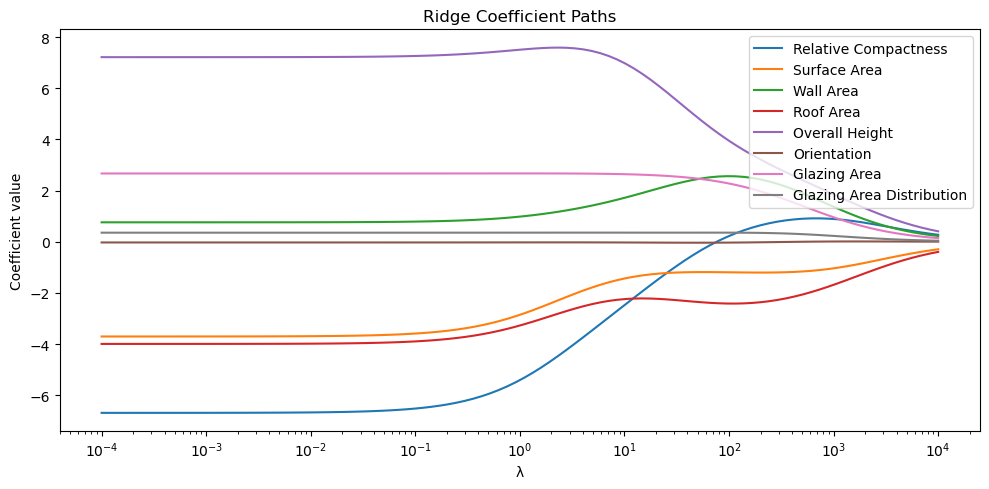

In [36]:
# Define a list to store the coefficents
coef = []
# Recall range of lambda values 
lambdas = np.logspace(-4, 4, 100)

# Loop through different values of lambda
for l in lambdas:
    ridge = Ridge(alpha=l)
    ridge.fit(X_train_scaled, y_train)
    coef.append(ridge.coef_)

plt.figure(figsize=(10, 5))
plt.plot(lambdas, coef)
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Coefficient value')
plt.title('Ridge Coefficient Paths')
plt.legend(X_train.columns) # Add labels for each line
plt.tight_layout()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

`Relative Compactness` and `Overall Height` are the most important predictors in the coefficient profile. This is because they have the largest coefficient values across the range of lambda values based on magnitude, indicating that they have a stronger influence on the target variable (`heating load`) compared to the other variables. Generally as lambda increases, the coefficients for these two predictors shrink but remain larger than those of the other variables. Both variables are also generally persistent across the range of lambda values; the other variables shrink to near zero much faster than these two predictors.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [39]:
# Fit LassoCV 
lasso_cv = LassoCV(alphas=lambdas, cv=10)
lasso_cv.fit(X_train_scaled, y_train)

# Print statement to make it clear which lambda is best
print(f"Best lambda: {lasso_cv.alpha_}")

# Build comparison table
lasso_coef_table = pd.DataFrame({
    "Feature": X_train.columns,
    "OLS Coefficient": ols_model.coef_,
    "Ridge Coefficient": ridge_cv.coef_,
    "Lasso Coefficient": lasso_cv.coef_
})

lasso_coef_table

Best lambda: 0.0016297508346206436


,Feature,OLS Coefficient,Ridge Coefficient,Lasso Coefficient
0,Relative Compactness,-6.386753e+01,-6.352418,-6.418330
1,Surface Area,-8.736463e+09,-3.474392,-6.231035
2,Wall Area,8.736463e+09,0.816587,2.152524
3,Roof Area,1.747293e+10,-3.797180,-1.044324
4,Overall Height,4.125574e+00,7.306373,7.309160
5,Orientation,-2.357210e-02,-0.025299,-0.023593
6,Glazing Area,1.992667e+01,2.670852,2.670194
7,Glazing Area Distribution,2.307234e-01,0.356417,0.354971


In [40]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

It is clear that both lasso and ridge shrank some of the coefficients; however, lasso increased some coefficients in terms of their magnitude. For example, `Wall Area` and `Roof Area` have larger coefficients in the lasso model compared to the ridge model, in terms of their magnitude; the lasso shrank these two coefficients less than ridge did. This is likely because lasso can set some coefficients to exactly zero while ridge shrinks coefficients towards zero but does not set them to zero. As a result, lasso may increase the magnitude of some coefficients while shrinking others to zero whereas ridge will generally shrink all coefficients more uniformly. There did not seem to be any significant differences in the coefficients for `Overall Height`, `Orientation`, `Glazing Area`, and `Glazing Area Distribution` between the two models when compared to the original OLS coefficients.

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [ ]:
# Predict on scaled X_test
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)

# Print statement to show MSE 
print(f"Best Lasso CV MSE: {mse_lcv:.4f}")

Best Lasso CV MSE: 8.8416


In [42]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [ ]:
# Create table to compare MSEs
mse_table = pd.DataFrame({
    "Model": ["OLS", "Ridge CV", "Lasso CV"],
    "Test MSE": [mse_ols, mse_rcv, mse_lcv]
})
mse_table

,Model,Test MSE
0,OLS,8.840180
1,Ridge CV,8.843961
2,Lasso CV,8.841571


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

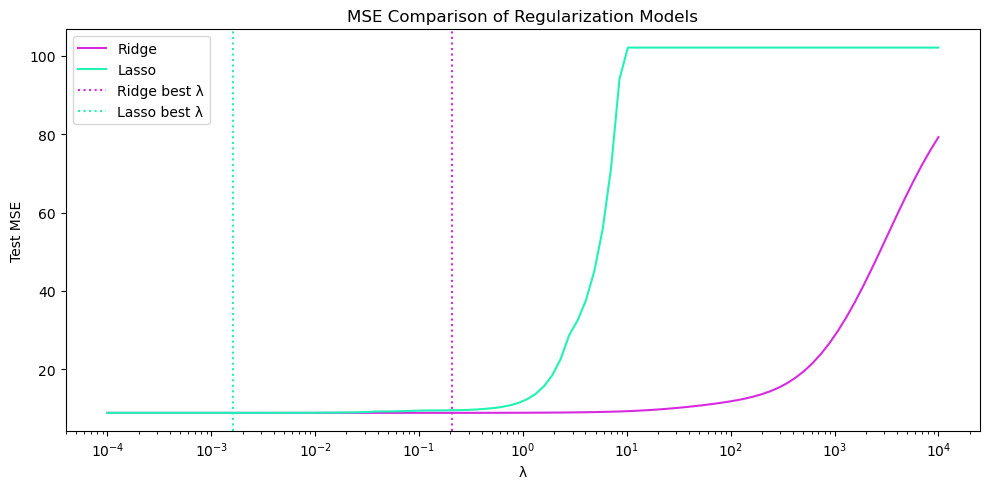

In [49]:
# Create plot
# Create empty lists to store MSE values for each lambda
mse_ridge_path = []
mse_lasso_path = []
# Recall range of lambda values 
lambdas = np.logspace(-4, 4, 100)
# Loop through different lambdas
for l in lambdas:
    ridge = Ridge(alpha=l)
    lasso = Lasso(alpha=l)
    ridge.fit(X_train_scaled, y_train)
    lasso.fit(X_train_scaled, y_train)
    mse_ridge_path.append(mean_squared_error(y_test, ridge.predict(X_test_scaled)))
    mse_lasso_path.append(mean_squared_error(y_test, lasso.predict(X_test_scaled)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_ridge_path, label='Ridge', color='#D72BE0')
plt.plot(lambdas, mse_lasso_path, label='Lasso', color='#21F3B4')

# It is useful to add vertical lines to visually indicate where best lambda is for each model
plt.axvline(ridge_cv.alpha_, color="#D72BE0", linestyle=':', label=f'Ridge best λ')
plt.axvline(lasso_cv.alpha_, color="#21F3B4", linestyle=':', label=f'Lasso best λ')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Test MSE')
plt.title('MSE Comparison of Regularization Models')
plt.legend()
plt.tight_layout()
plt.show()

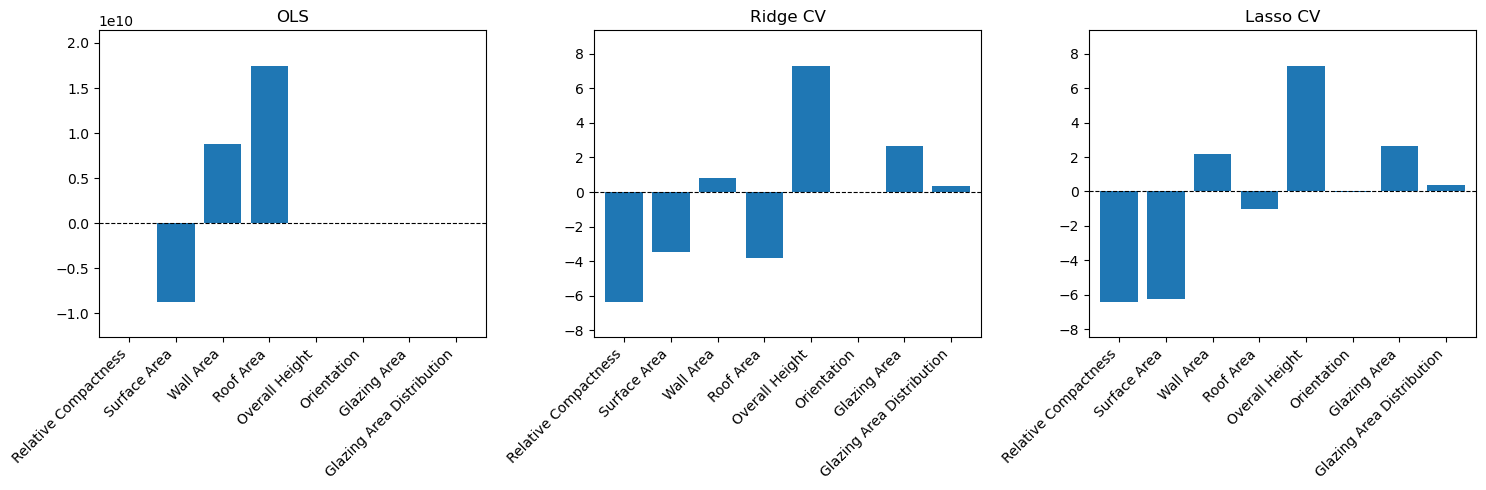

In [52]:
# Create bar plot to compare coefficients across models 
models = {
    'OLS': ols_model.coef_,
    'Ridge CV': ridge_cv.coef_,
    'Lasso CV': lasso_cv.coef_
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

# Use faceted approach to plot coefficients for each model
for i, (name, coefs) in enumerate(models.items()):
    df = pd.DataFrame({name: coefs}, index=X_train.columns)
    df.plot.bar(ax=axes[i], width=0.8, legend=False)
    axes[i].set_title(name)
    axes[i].set_xticklabels(df.index, rotation=45, ha='right')
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    ymin = min(df.values.min(), 0)
    ymax = max(df.values.max(), 0)
    pad = max((ymax - ymin) * 0.15, 0.5)
    axes[i].set_ylim(ymin - pad, ymax + pad)

plt.tight_layout()
plt.show()

> **Q4: Which model would you pick for this dataset? Why?**

I would choose the ridge model for this dataset because OLS is unusable with multicollinearity among its features. Both lasso and ridge fix this issue and predict equally well; however, lasso seems to have concentrated the correlation effect in `Surface Area` while the ridge distributes it more evenly.

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [62]:
# Fit PCA with all components
pca_full = PCA(n_components=8)
pca_full.fit(X_train_scaled)

# Store explained + cumulative variance
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)


variance_table = pd.DataFrame({
    "Component": [f"PC{i}" for i in range(len(explained_var))], # Loop through each component and create label
    "Explained Variance (%)": explained_var * 100,
    "Cumulative Variance (%)": cumulative_var * 100
})
variance_table

,Component,Explained Variance (%),Cumulative Variance (%)
0,PC0,4.629048e+01,46.290475
1,PC1,1.563182e+01,61.922293
2,PC2,1.497484e+01,76.897136
3,PC3,1.243148e+01,89.328613
4,PC4,9.966322e+00,99.294935
5,PC5,6.477268e-01,99.942662
6,PC6,5.733790e-02,100.000000
7,PC7,2.730130e-30,100.000000


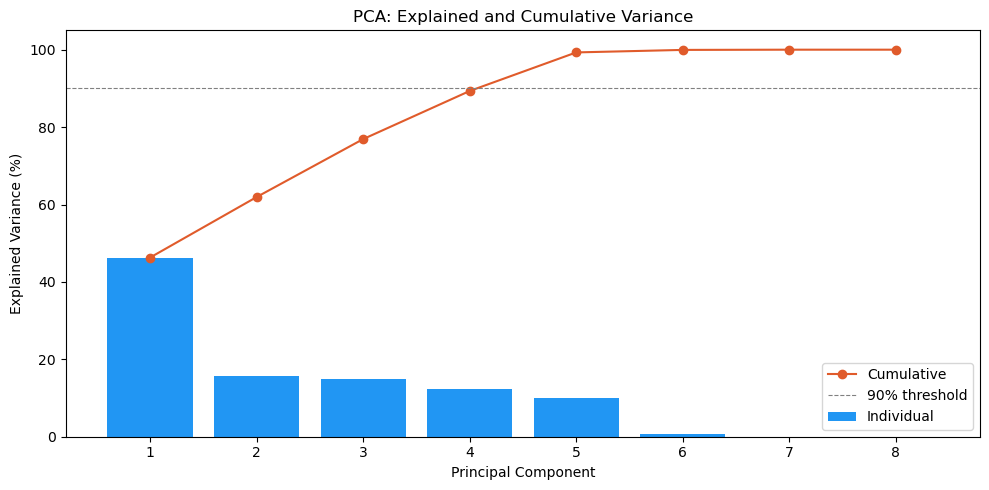

In [ ]:
# Create plot with range of 1 to 100
components = np.arange(1, len(explained_var) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(components, explained_var * 100, color='#2196F3', label='Individual')
ax.plot(components, cumulative_var * 100, color='#E05B2B', marker='o', label='Cumulative')
ax.axhline(90, color='gray', linestyle='--', linewidth=0.8, label='Threshold') # Add 90% threshold line
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('PCA: Explained and Cumulative Variance')
ax.set_xticks(components)
ax.legend()
plt.tight_layout()
plt.show()

In [57]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It takes about 4 principal components to explain at least 90% of the variance in the features.

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [63]:
# Set k based on the elbow / ~90% cumulative variance threshold in the plot above
best_k = 4

pca_final = PCA(n_components=best_k)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

ols_pcr = LinearRegression()

y_pred_pcr = ols_pcr.fit(X_train_pca, y_train).predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)
print(f"PCR MSE: {mse_pcr:.4f}")



PCR MSE: 14.5239


<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

Based on the cumulative variance, it takes about 4 principal components to explain at least 90% of the variance in the features. As such, I would pick k = 4 for the PCR model. Picking an additional PC beyond 4 would not add much explanatory power since the cumulative variance is already above 90% at that point. Additionally, we typically want the most parsimonious model that still explains a significant portion of the variance. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [65]:
# We can create a table that compares each accuracy metric 
summary_table = pd.DataFrame({
    "Model": ["OLS", "Ridge CV", "Lasso CV", "PCR"], # Models
    "Tuning Parameter": [
        "None", # OLS does not have tuning parameter
        f"λ = {ridge_cv.alpha_:.4f}",
        f"λ = {lasso_cv.alpha_:.4f}",
        f"k = {best_k} components"
    ],
    "Test MSE": [mse_ols, mse_rcv, mse_lcv, mse_pcr]
})
summary_table

,Model,Tuning Parameter,Test MSE
0,OLS,None,8.840180
1,Ridge CV,λ = 0.2057,8.843961
2,Lasso CV,λ = 0.0016,8.841571
3,PCR,k = 4 components,14.523853


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

Interestingly, the OLS, ridge, and lasso models perform similarly based on the test MSEs of 8.84, 8.84, and 8.84 respectively. These differences are negligible. PCR is an obvious outlier given its test MSE of 14.52 is much higher compared to the other three linear models. 


<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [66]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!